In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np

from mad.configs.planets import EARTH_SETTINGS
from mad.objs.projectiles import Projectile, ProjectileConfig
from mad.objs.planets import Planet, PlanetConfig
from mad.logger import SourceLogger
import matplotlib.pyplot as plt

logger = SourceLogger()

In [3]:
EARTH_SETTINGS["position"] = [0.0, 0.0]
earth = Planet(PlanetConfig(**EARTH_SETTINGS))

earth

Planet Earth at [0. 0. 0.]
Mass 5.97e+24 kg, Radius 6371.0 km.
Gravity at surface: -9.82 m/s^2
Orbital velocity: 7909.55 m/s
Escape velocity: 11185.79 m/s

In [4]:
projectile_cfg = ProjectileConfig(
    **{
        "position": [earth.radius + 1000, 0.0],
        "mass": 50,
        "area": 0.,
        "velocity": [0, earth.orbital_velocity*1.2],
    }
)

proj = Projectile(projectile_cfg)
dt = 1
t = 0.0
time_scale = [t]
while t < 20000:
    proj.integrate(dt, planet=earth)

    time_scale.append(t)
    t += dt
    if not proj.active:
        break

logger["Simulation"].info(f" Simulation ended at {t:.2f}")

15:21:17 | INFO     | Simulation   |  Simulation ended at 20000.00


In [5]:
pos = np.asarray(proj.history.position)
vel = np.asarray(proj.history.velocity)

posx, posz = pos[:, 0], pos[:, 1]

altitude = np.linalg.norm(pos, axis=1) - earth.radius
velout = np.linalg.norm(vel, axis=1)

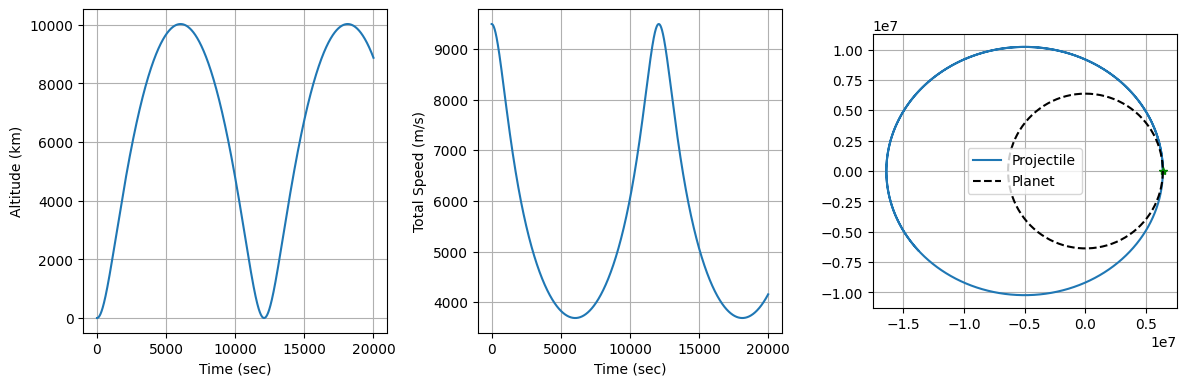

In [6]:
fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(12, 4))
ax.flatten()

ax[0].plot(time_scale, altitude/1000)
ax[0].set_xlabel("Time (sec)")
ax[0].set_ylabel("Altitude (km)")
ax[0].grid()

ax[1].plot(time_scale, velout)
ax[1].set_xlabel("Time (sec)")
ax[1].set_ylabel("Total Speed (m/s)")
ax[1].grid()

ax[2].plot(posx, posz, label="Projectile")
ax[2].plot(posx[0], posz[0], "g*")
theta = np.linspace(0, 2 * np.pi, 100)
xplanet = earth.radius * np.sin(theta)
yplanet = earth.radius * np.cos(theta)
ax[2].plot(xplanet, yplanet, "k--", label="Planet")
ax[2].set_aspect("equal")
ax[2].grid()
ax[2].legend()

fig.tight_layout(pad=1.2)